## TD法
+ 連続タスクもしくはエピソードタスクに適用可能
+ 終わりがない連続タスクに対して適用する. e.g. 自動車の進路経路
+ MC法とDP法の折衷案で方策評価を行う
+ TD法はブートストラップ(推定値で推定値を更新する)
+ 方策制御には方策オン型と方策オフ型など複数のバリエーションがある。

MC法
+ 収益 $G_{t} = R_{t} + \gamma R_{t+1} + \gamma^{2} R_{t+2} + ...$ を実際に複数のエピソードを通して得る
+ 各状態における収益$G_{t}$を大数の法則に基づいて平均で近似する
$$v_{\pi}(s) = E_{\pi}[G_{t}|S_{t}=s]$$
$$V'_`{\pi}(S_{t}) = V_{\pi}(S_{t}) + \alpha \{G_{t} - V_{\pi}(S_{t}) \}$$

DP法
+ 状態$S_{t}$において、次に考えられる全ての選択となる$s' \in S_{t+1}$を用いる
$$v_{\pi}(s) = E_{\pi}[R_{t} + \gamma G_{t+1} | S_{t} = s]$$
$$V'_{\pi}(s) = \sum_{a} \pi(a|s) \sum_{s'} p(s'|s,a) \{ r(s,a,s') + \gamma v_{\pi}(s') \}$$

TD法
+ 状態$S_{t}$から次の状態$S_{t+1}$の中から一つの状態を選択して、実際にサンプリングしてデータを得る
+ 次の選択における価値関数$v_{\pi}(S_{t+1})$を用いて、状態$S_{t}$の価値関数$v_{\pi}(S_{t})$を更新する

$$v_{\pi}(s) = E_{\pi}[R_{t} + \gamma v_{\pi}(S_{t+1})|S_{t}=s]$$
$$V'_{\pi}(S_{t}) = V_{\pi}(S_{t}) + \alpha \{ R_{t} + \gamma V_{\pi}(S_{t+1}) - V_{\pi}(S_{t}) \}$$

+ TD(1)ターゲット : $R_{t} + \gamma V_{\pi}(S_{t+1})$
+ TDターゲットは, MC法の報酬$G_{t}$を置き換えたもの

In [2]:
from collections import defaultdict
import numpy as np

# TD(1)法
class TdAgent:
    def __init__(self):
        self.gamma = 0.9
        self.alpha = 0.01
        self.action_size = 4

        random_actions = {
            0: .25,
            1: .25,
            2: .25,
            3: .25,
        }

        self.pi = defaultdict(lambda: random_actions)
        self.V = defaultdict(lambda: 0)

    def get_action(self, state):
        action_probs = self.pi[state]
        actions = list(action_probs.keys())
        probs = list(action_probs.values())
        return np.random.choice(actions, p=probs)

    # ここがDP法と異なる: 状態stateで行動actionを行い、報酬rewardを得て、次の状態next_stateに進んだ時に実行される.
    def eval(self, state, reward, next_state, done):
        next_V = 0 if done else self.V[next_state] # ゴールは価値関数の値は0
        target = reward + self.gamma * next_V
        self.V[state] += self.alpha * (target - self.V[state])


In [3]:
# 描画用
import numpy as np
import matplotlib
import matplotlib_inline
import matplotlib.pyplot as plt

class Renderer:
    def __init__(self, reward_map, goal_state, wall_state):
        self.reward_map = reward_map
        self.goal_state = goal_state
        self.wall_state = wall_state
        self.ys = len(self.reward_map)
        self.xs = len(self.reward_map[0])

        self.ax = None
        self.fig = None
        self.first_flg = True

    def set_figure(self, figsize=None):
        fig = plt.figure(figsize=figsize)
        self.ax = fig.add_subplot(111)
        ax = self.ax
        ax.clear()
        ax.tick_params(labelbottom=False, labelleft=False, labelright=False, labeltop=False)
        ax.set_xticks(range(self.xs))
        ax.set_yticks(range(self.ys))
        ax.set_xlim(0, self.xs)
        ax.set_ylim(0, self.ys)
        ax.grid(True)

    def render_v(self, v=None, policy=None, print_value=True):
        self.set_figure()

        ys, xs = self.ys, self.xs
        ax = self.ax

        if v is not None:
            color_list = ['red', 'white', 'green']
            cmap = matplotlib.colors.LinearSegmentedColormap.from_list(
                'colormap_name', color_list)

            # dict -> ndarray
            v_dict = v
            v = np.zeros(self.reward_map.shape)
            for state, value in v_dict.items():
                v[state] = value

            vmax, vmin = v.max(), v.min()
            vmax = max(vmax, abs(vmin))
            vmin = -1 * vmax
            vmax = 1 if vmax < 1 else vmax
            vmin = -1 if vmin > -1 else vmin

            ax.pcolormesh(np.flipud(v), cmap=cmap, vmin=vmin, vmax=vmax)

        for y in range(ys):
            for x in range(xs):
                state = (y, x)
                r = self.reward_map[y, x]
                if r != 0 and r is not None:
                    txt = 'R ' + str(r)
                    if state == self.goal_state:
                        txt = txt + ' (GOAL)'
                    ax.text(x+.1, ys-y-0.9, txt)

                if (v is not None) and state != self.wall_state:
                    if print_value:
                        offsets = [(0.4, -0.15), (-0.15, -0.3)]
                        key = 0
                        if v.shape[0] > 7: key = 1
                        offset = offsets[key]
                        ax.text(x+offset[0], ys-y+offset[1], "{:12.2f}".format(v[y, x]))

                if policy is not None and state != self.wall_state:
                    actions = policy[state]
                    max_actions = [kv[0] for kv in actions.items() if kv[1] == max(actions.values())]

                    arrows = ["↑", "↓", "←", "→"]
                    offsets = [(0, 0.1), (0, -0.1), (-0.1, 0), (0.1, 0)]
                    for action in max_actions:
                        arrow = arrows[action]
                        offset = offsets[action]
                        if state == self.goal_state:
                            continue
                        ax.text(x+0.45+offset[0], ys-y-0.5+offset[1], arrow)

                if state == self.wall_state:
                    ax.add_patch(plt.Rectangle((x,ys-y-1), 1, 1, fc=(0.4, 0.4, 0.4, 1.)))
        plt.show()

    def render_q(self, q, show_greedy_policy=True):
        self.set_figure()

        ys, xs = self.ys, self.xs
        ax = self.ax
        action_space = [0, 1, 2, 3]

        qmax, qmin = max(q.values()), min(q.values())
        qmax = max(qmax, abs(qmin))
        qmin = -1 * qmax
        qmax = 1 if qmax < 1 else qmax
        qmin = -1 if qmin > -1 else qmin


        color_list = ['red', 'white', 'green']
        cmap = matplotlib.colors.LinearSegmentedColormap.from_list(
            'colormap_name', color_list)

        for y in range(ys):
            for x in range(xs):
                for action in action_space:
                    state = (y, x)
                    r = self.reward_map[y, x]
                    if r != 0 and r is not None:
                        txt = 'R ' + str(r)
                        if state == self.goal_state:
                            txt = txt + ' (GOAL)'
                        ax.text(x+.05, ys-y-0.95, txt)

                    if state == self.goal_state:
                        continue

                    tx, ty = x, ys-y-1

                    action_map = {
                        0: ((0.5+tx, 0.5+ty), (tx+1, ty+1), (tx, ty+1)),
                        1: ((tx, ty), (tx+1, ty), (tx+0.5, ty+0.5)),
                        2: ((tx, ty), (tx+0.5, ty+0.5), (tx, ty+1)),
                        3: ((0.5+tx, 0.5+ty), (tx+1, ty), (tx+1, ty+1)),
                    }
                    offset_map = {
                        0: (0.1, 0.8),
                        1: (0.1, 0.1),
                        2: (-0.2, 0.4),
                        3: (0.4, 0.4),
                    }
                    if state == self.wall_state:
                        ax.add_patch(plt.Rectangle((tx, ty), 1, 1, fc=(0.4, 0.4, 0.4, 1.)))
                    elif state in self.goal_state:
                        ax.add_patch(plt.Rectangle((tx, ty), 1, 1, fc=(0., 1., 0., 1.)))
                    else:

                        tq = q[(state, action)]
                        color_scale = 0.5 + (tq / qmax) / 2  # normalize: 0.0-1.0

                        poly = plt.Polygon(action_map[action],fc=cmap(color_scale))
                        ax.add_patch(poly)

                        offset= offset_map[action]
                        ax.text(tx+offset[0], ty+offset[1], "{:12.2f}".format(tq))
        plt.show()

        if show_greedy_policy:
            policy = {}
            for y in range(self.ys):
                for x in range(self.xs):
                    state = (y, x)
                    qs = [q[state, action] for action in range(4)]  # action_size
                    max_action = np.argmax(qs)
                    probs = {0:0.0, 1:0.0, 2:0.0, 3:0.0}
                    probs[max_action] = 1
                    policy[state] = probs
            self.render_v(None, policy)



In [4]:
import numpy as np

class GridWorld:
    def __init__(self):
        self.action_space = [0,1,2,3]
        self.action_meaning = {
            0: 'UP', 1: 'DOWN', 2: 'LEFT', 3: 'RIGHT'
        }

        # 報酬マップ
        self.reward_map = np.array([
            [0, 0, 0, 1.0],
            [0, None, 0, -1.0],
            [0, 0, 0, 0]
        ])

        self.goal_state = (0,3) # reward: 1.0
        self.wall_state = (1,1) # None
        self.start_state = (2,0) # 左下隅
        self.agent_state = self.start_state

    @property
    def height(self):
        return len(self.reward_map)
    
    @property
    def width(self):
        return len(self.reward_map[0])
    
    @property
    def shape(self):
        return self.reward_map.shape
    
    def actions(self):
        return self.action_space
    
    # ジェネレータ
    def states(self):
        for h in range(self.height):
            for w in range(self.width):
                yield (h,w)

    # 状態遷移関数
    def next_state(self, state, action): # p(s'|s,a)
        # print(f'state: {state}')

        # 1. 移動先の場所の計算
        action_move_map = [
            (-1,0), # 上
            (1,0),  # 下
            (0,-1), # 左
            (0,1)   # 右
        ]
        move = action_move_map[action]
        # print(f'move: {move}')
        next_state = (state[0] + move[0], state[1] + move[1])
        # print(f'next_state: {next_state}')
        ny, nx = next_state

        # 2. 移動先がグリッドワールドの枠の外か、それとも移動先が壁か?
        if nx < 0 or nx >= self.width or ny < 0 or ny >= self.height:
            next_state = state
        elif next_state == self.wall_state:
            next_state = state

        return next_state # 3. 状態遷移は決定論的なので関数の結果を返すだけ.
    
    # 報酬関数
    def reward(self, state, action, next_state): # r(s',s,a)
        # 今回はエージェントの行動や前回の状態ｓに依存はなく、状態遷移後の状態s'のみに報酬は依存する
        return self.reward_map[next_state]
    
    def reset(self):
        self.agent_state = self.start_state
        return self.agent_state
    
    # エージェントに方策πに従って一つ行動させる
    def step(self, action):
        state = self.agent_state
        next_state = self.next_state(state, action) # 状態遷移
        reward = self.reward(state, action, next_state) # 得られた報酬
        done = (next_state == self.goal_state) # 収束条件

        self.agent_state = next_state # エージェントが置かれた状態を更新
        return next_state, reward, done
    
    def render_v(self, v=None, policy=None, print_value=True):
        # 状態価値Vの可視化
        renderer = Renderer(self.reward_map,
                                            self.goal_state,
                                            self.wall_state)
        renderer.render_v(v, policy, print_value)

    def render_q(self, q=None, print_value=True):
        # 行動価値Qの可視化
        renderer = Renderer(self.reward_map,
                                          self.goal_state,
                                          self.wall_state)
        renderer.render_q(q, print_value)

In [5]:
def move(action):
    if action == 0:
        return '↓'
    elif action == 1:
        return '↑'
    elif action == 2:
        return '←'
    elif action == 3:
        return '→'
    else:
        raise NotImplementedError

エージェントを実際に動かして方策評価を行う

Ep[0]/St[23] state: (1, 3), action: 0:↓, reward: 1.0


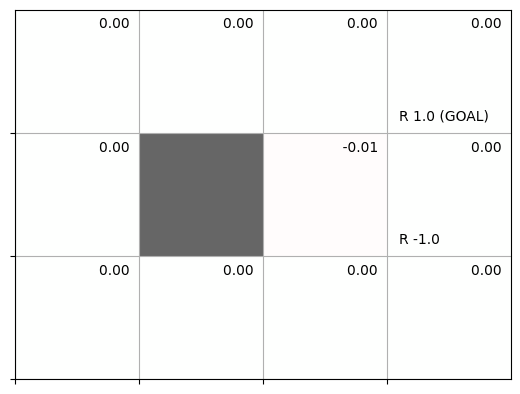

Ep[100]/St[22] state: (0, 2), action: 3:→, reward: 1.0


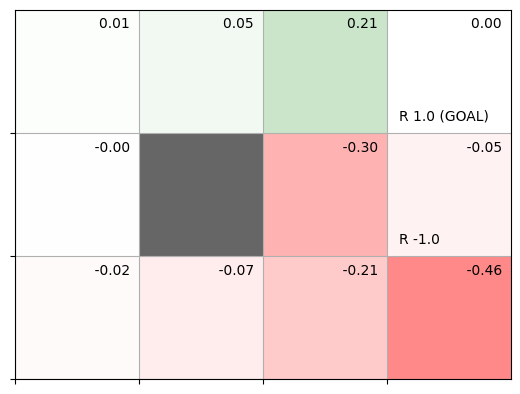

Ep[200]/St[16] state: (0, 2), action: 3:→, reward: 1.0


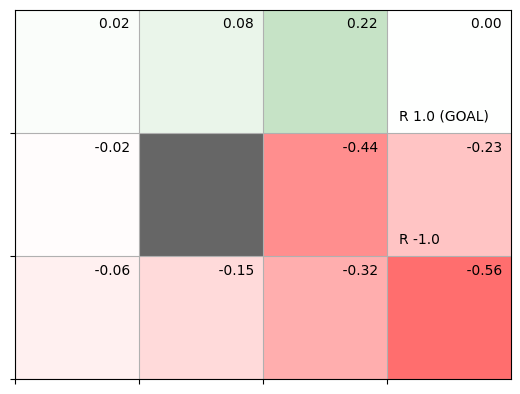

Ep[300]/St[100] state: (0, 2), action: 3:→, reward: 1.0


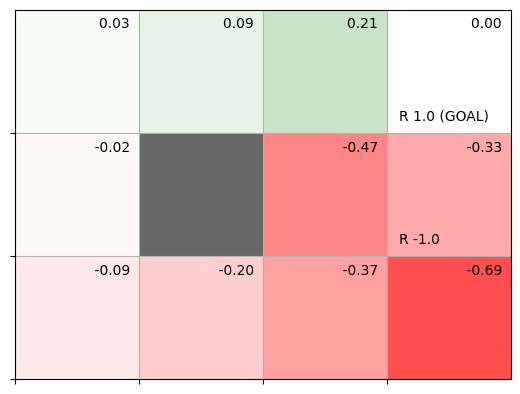

Ep[400]/St[14] state: (0, 2), action: 3:→, reward: 1.0


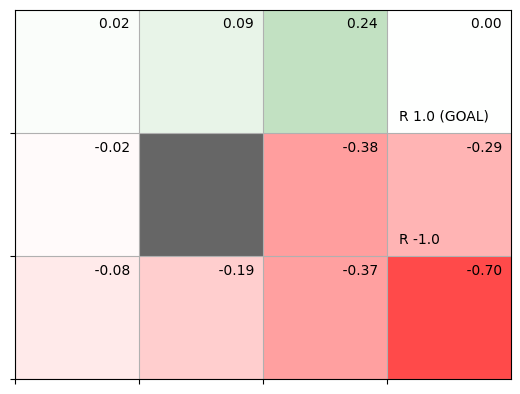

Ep[500]/St[32] state: (0, 2), action: 3:→, reward: 1.0


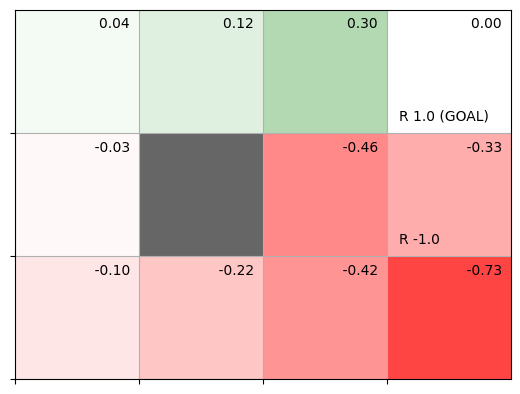

Ep[600]/St[29] state: (0, 2), action: 3:→, reward: 1.0


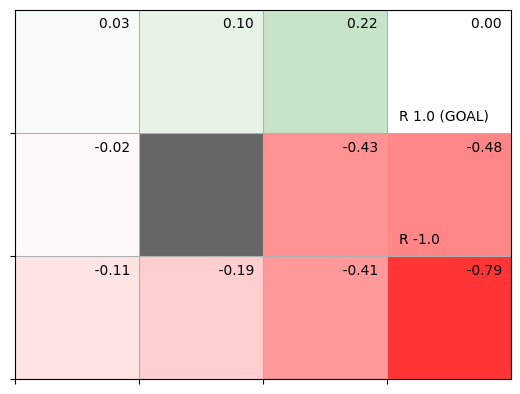

Ep[700]/St[30] state: (1, 3), action: 0:↓, reward: 1.0


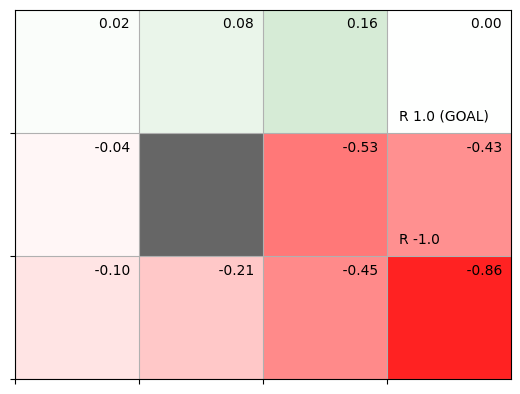

Ep[800]/St[34] state: (1, 3), action: 0:↓, reward: 1.0


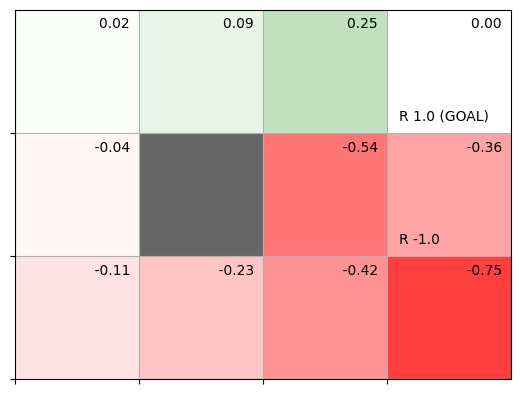

Ep[900]/St[38] state: (0, 2), action: 3:→, reward: 1.0


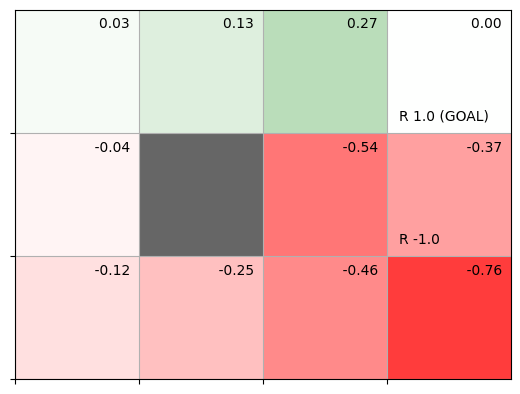

Result of eval V-map


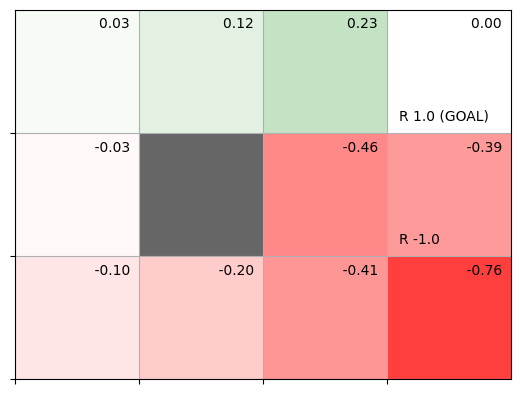

In [6]:
env = GridWorld()
agent = TdAgent()

episodes = 1000
for episode in range(episodes):
    state = env.reset()
    step = 0

    # 1EPにおけるエージェントの行動と状態遷移
    while True:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)

        # ここがMC法と異なる. 1状態進むごとに学習する
        agent.eval(state, reward, next_state, done)

        if done:
            break

        # 状態遷移(ここでは決定論的)
        state = next_state

        step += 1

    if episode % 100 == 0:
        print(f"Ep[{episode}]/St[{step}] state: {state}, action: {action}:{move(action)}, reward: {reward}")
        env.render_v(agent.V)

# TD法による方策評価の結果
print('Result of eval V-map') 
env.render_v(agent.V)

方策オン型: SARSA法による方策制御
+ 方策制御を行うには状態価値関数$V_{\pi}(s)$ではなく行動価値関数$Q_{\pi}(s,a)$を対象にしなければならない.
+ 方策の改善にはε-greedy法以外にもさまざまなものがある。
+ 状態価値関数$V_{\pi}(s)$を使って、方策改善を行うには、環境モデルが必要.
+ 行動価値関数$Q_{\pi}(s,a)$を直接使うと、方策改善で環境モデルが不要.

$$\mu(s) = argmax_{a}　Q_{\pi}(s,a)$$

行動価値関数を対象にしたTD法
$$Q'_{\pi}(S_{t},A_{t}) = Q_{\pi}(S_{t},A_{t}) + \alpha \{ R_{t} + \gamma Q_{\pi}(S_{t+1},A_{t+1}) - Q_{\pi}(S_{t},A_{t}) \}$$
+ ターゲット: $R_{t} + \gamma Q_{\pi}(S_{t+1},A_{t+1})$
+ 方策評価するだけなら, 状態価値関数Vだけわかれば良い、方策制御を行うには行動価値関数Qが必要

方策オン型の方策制御では、方策制御を完全にgreedy化できない. ε-greedy法などの準greedy法を使う
+ $(S_t,A_t,R_t,S_{t+1},A_{t+1})$ が得られた場合, 行動価値関数を対象にしたTD法で方策制御できる

$$
\pi'(a|S_t) = 
\begin{cases} 
  argmax_{a}Q_{\pi}(s,a), & (1-\epsilon)  \\
  ランダムな行動,   & \epsilon
\end{cases}
$$

In [8]:
# ε-greedy法
def greedy_probs(Q, state, epsilon=0, action_size=4):
    qs = [Q[(state,action)] for action in range(action_size)]
    max_action = np.argmax(qs)

    base_prob = epsilon / action_size
    action_probs = { action: base_prob for action in range(action_size) }
    # この時点でaction_probsは {0: ε/4, 1: ε/4, 2: ε/4, 3: ε/4}
    action_probs[max_action] += (1 - epsilon) # ε/4 + (1 - ε) = 1 - 3ε/4. sum = ε/4 + (1-3ε/4) + ε/4 + ε/4 = 1.0
    return action_probs

In [9]:
# 方策オン型の方策制御では、方策制御を完全にgreedy化できない. ここではε-greedy法を使う

from collections import deque

class SarsaAgent:
    def __init__(self):
        self.gamma = 0.9
        self.alpha = 0.8
        self.epsilon = 0.1
        self.action_size = 4

        random_actions = {
            0: .25,
            1: .25,
            2: .25,
            3: .25,
        }

        self.pi = defaultdict(lambda: random_actions)
        self.Q = defaultdict(lambda: 0) # 行動価値関数
        self.memory = deque(maxlen=2)   # TD1法ではmaxlen=2

    def get_action(self, state):
        action_probs = self.pi[state]
        actions = list(action_probs.keys())
        probs = list(action_probs.values())
        return np.random.choice(actions, p=probs)
    
    def reset(self):
        self.memory.clear()

    def update(self, state, action, reward, done):
        self.memory.append((state, action, reward, done)) # 1ステップ進んで経験する
        if len(self.memory) < 2:
            return
        
        state, action, reward, done = self.memory[0]
        next_state, next_action, _, _ = self.memory[1]

        # 次のQ関数
        next_q = 0 if done else self.Q[next_state, next_action]

        # TD法による更新
        target = reward + self.gamma * next_q
        self.Q[state, action] += self.alpha * (target - self.Q[state, action])

        # 方策改善
        self.pi[state] = greedy_probs(self.Q, state, self.epsilon)

    

TD法&SARSA法で3x4グリッドワールドにエージェントを行動させてみる

Ep[0]/St[735] state: (0, 2), action: 3:→, reward: 1.0


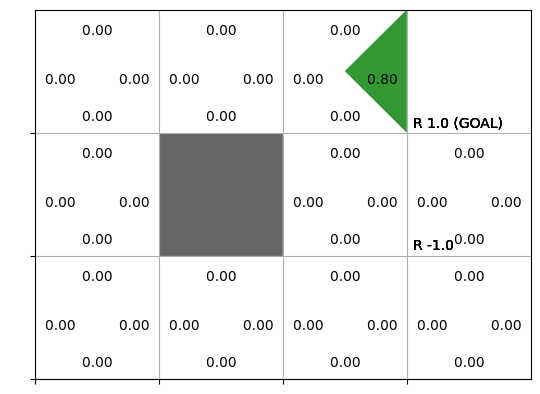

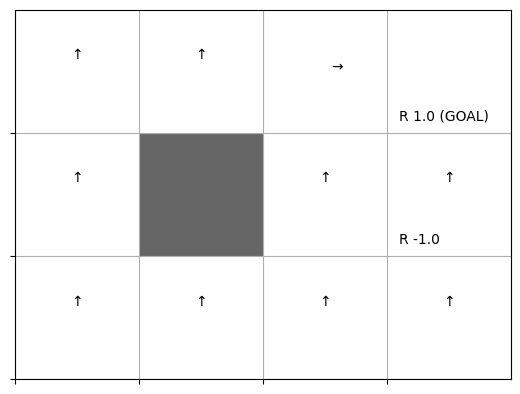

Ep[1000]/St[4] state: (0, 2), action: 3:→, reward: 1.0


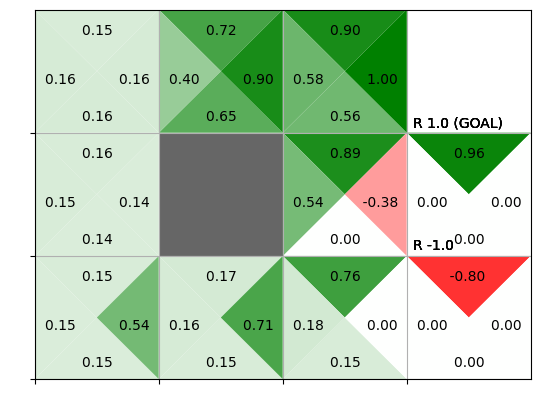

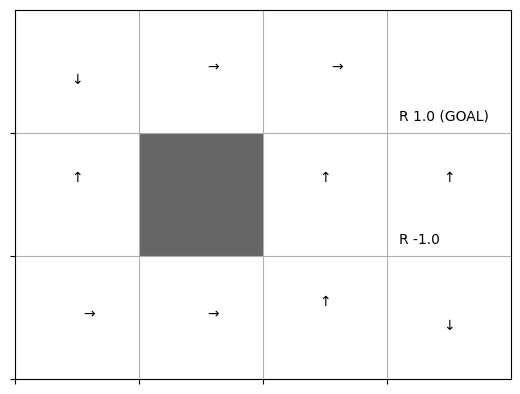

Ep[2000]/St[13] state: (0, 2), action: 3:→, reward: 1.0


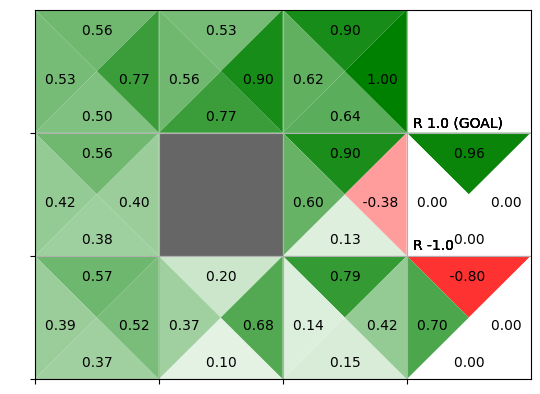

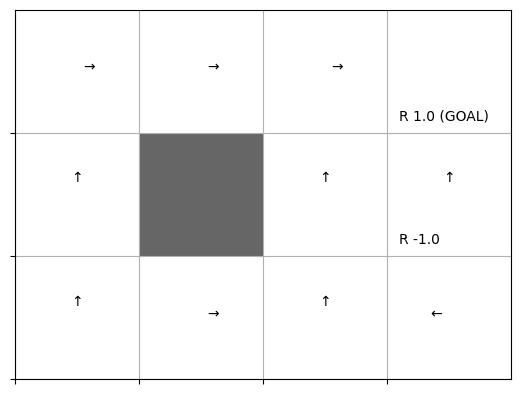

Ep[3000]/St[4] state: (0, 2), action: 3:→, reward: 1.0


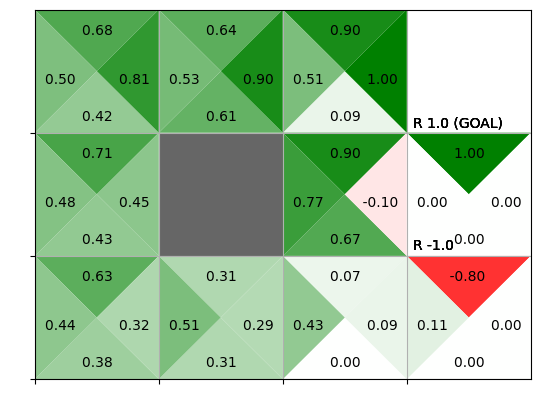

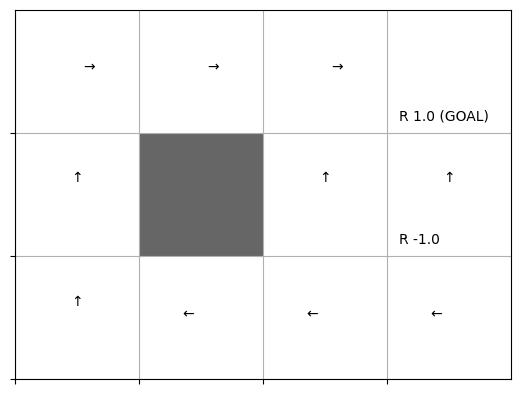

Ep[4000]/St[4] state: (0, 2), action: 3:→, reward: 1.0


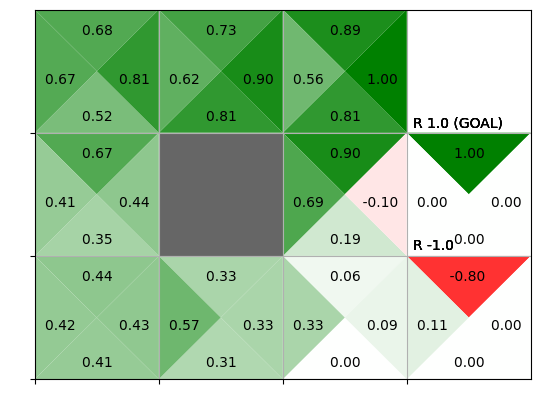

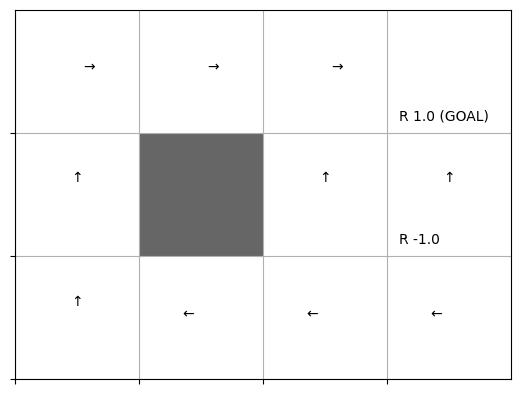

Ep[5000]/St[9] state: (0, 2), action: 3:→, reward: 1.0


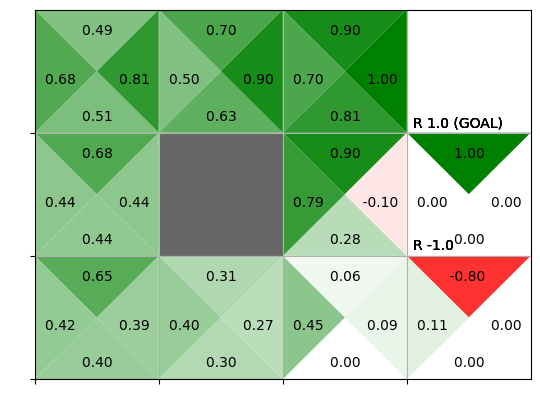

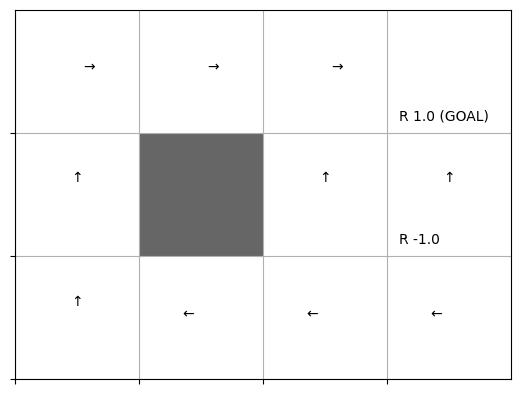

Ep[6000]/St[4] state: (0, 2), action: 3:→, reward: 1.0


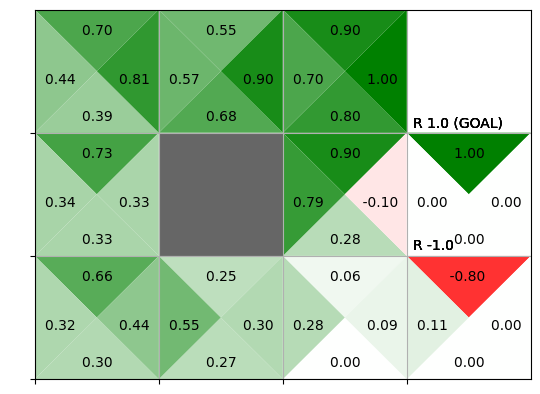

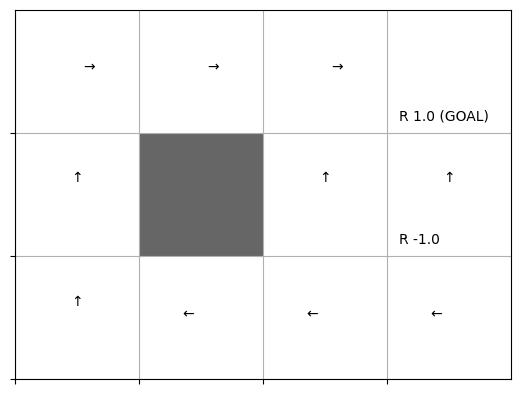

Ep[7000]/St[12] state: (0, 2), action: 3:→, reward: 1.0


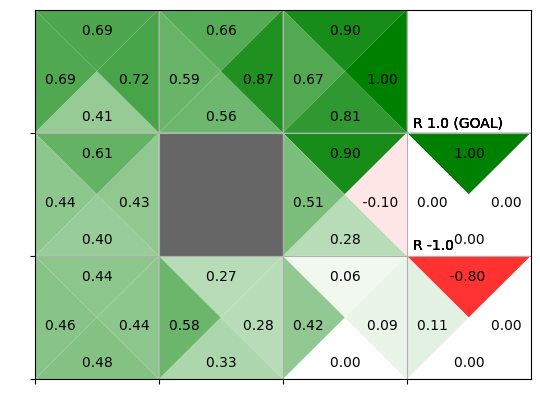

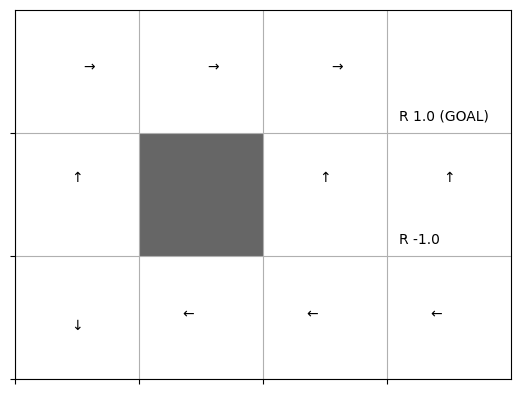

Ep[8000]/St[4] state: (0, 2), action: 3:→, reward: 1.0


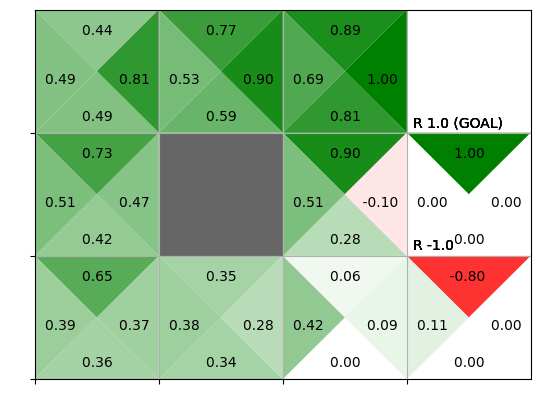

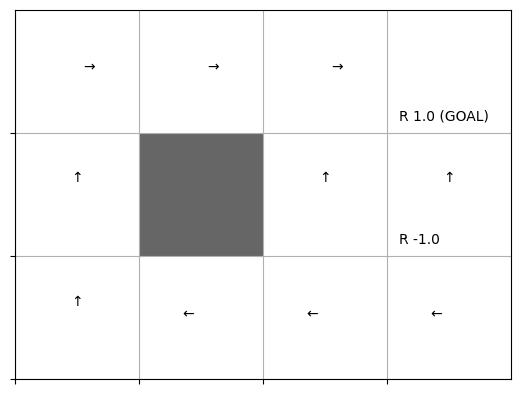

Ep[9000]/St[4] state: (0, 2), action: 3:→, reward: 1.0


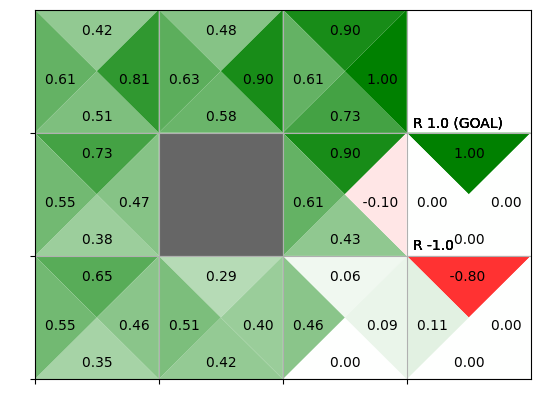

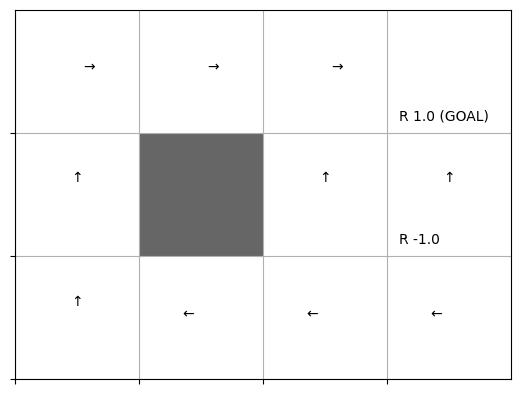

Result of eval Q-map


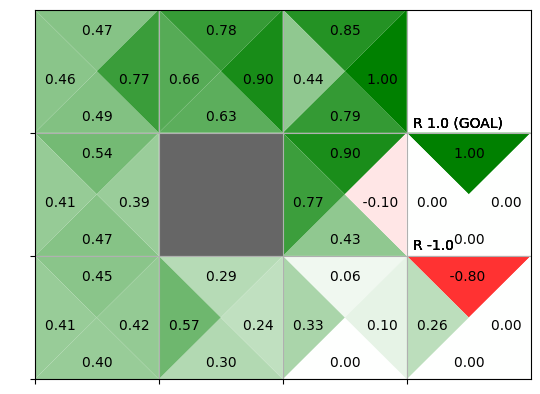

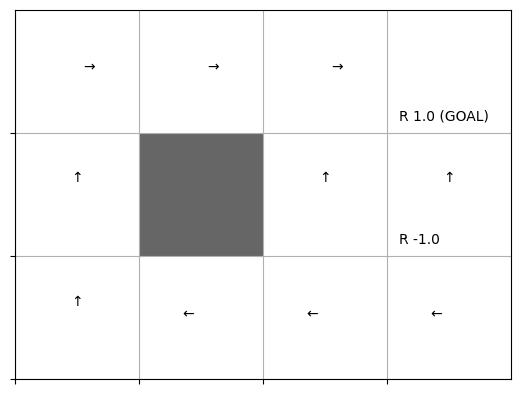

In [14]:
env = GridWorld()
agent = SarsaAgent()

episodes = 10000
for episode in range(episodes):
    state = env.reset()
    agent.reset()
    step = 0

    while True:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)

        agent.update(state, action, reward, done) # 毎回呼ぶ

        if done:
            # ゴールに到達した時も呼ぶ
            agent.update(next_state, None, None, None)
            break

        # 決定論的状態遷移
        state = next_state

        step += 1

    if episode % 1000 == 0:
        print(f"Ep[{episode}]/St[{step}] state: {state}, action: {action}:{move(action)}, reward: {reward}")
        env.render_q(agent.Q)

# TD法による方策評価の結果
print('Result of eval Q-map') 
env.render_q(agent.Q)